# Práctica 5. Ley de Malus
**Mediciones en Óptica y Acústica** · Prof. Omar Olarte · UNAL

| | |
|---|---|
| **Integrantes** |  Andrés Motta ·Paul Martinez· Santiago Ospina |
---

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from google.colab import files


## 1. Polarización de la luz de la linterna


La luz de la linterna utilizada en este experimento puede considerarse ***no polarizada o muy débilmente polarizada***. Para llegar a esta conclusión se ideó un experimento que consistió en iluminar con la linterna un polarizador y hacerlo girar, idealmente a velocidad constante. Con el sensor de la aplicación Physics Toolbox se registraron el tiempo y la intensidad luminosa en lux. La intensidad transmitida no presentó cambios significativos, manteniéndose aproximadamente entre 1060 y 1180 lux, como se observa en la gráfica. Ademas un dato a tener en cuenta, los resultados mostraron que la intensidad después de pasar por el polarizador era aproximadamente la mitad de la intensidad original.

Si la luz hubiera estado linealmente polarizada, se esperaría una variación mucho más pronunciada de la intensidad al cambiar la orientación del polarizador.

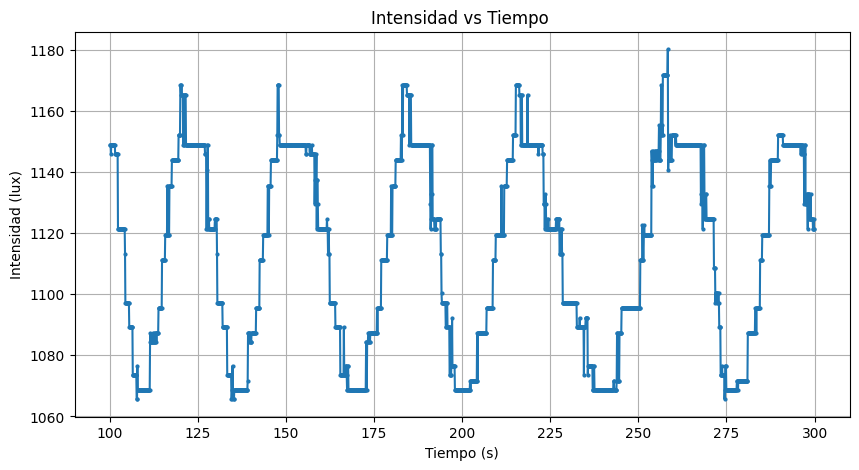

In [ ]:
df = pd.read_excel('POLARIZACION_LINTERNA.xlsx')
df.head()

tiempo = df.iloc[:,0]
intensidad = df.iloc[:,1]

filtro = (tiempo >= 100) & (tiempo <= 300)

tiempo_filtrado = tiempo[filtro]
intensidad_filtrada = intensidad[filtro]


plt.figure(figsize=(10,5))
plt.plot(tiempo_filtrado, intensidad_filtrada, 'o-', markersize=2)
plt.xlabel('Tiempo (s)')
plt.ylabel('Intensidad (lux)')
plt.title('Intensidad vs Tiempo ')
plt.grid(True)
plt.show()



##2. Estado de polarizacion de la luz de la linterna después de pasar por el primer polarizador y después de pasar por el segundo polarizador.

Como se dijo anteriormente, la luz de la linterna es principalmente no polarizada, pero al pasar por el primer polarizador basado en dicroísmo, la componente perpendicular al eje de transmisión del campo eléctrico es absorbida, por lo que la luz que se transmite es **linealmente polarizada**, en dirección vertical para estos polarizadores del experimento. Al atravesar el segundo polarizador, la luz continúa estando **linealmente polarizada**, pero observamos un cambio en la intensidad transmitida entre el ángulo relativo entre ambos polarizadores. Se observó experimentalmente que para un ángulo de 90 grados de diferencia entre polarizadores la intensidad varió de 2082 lux a 15 lux, esto cuando los polarizadores quedaron alineados perpendicularmente.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('MalusAngulos.csv', sep=';', decimal=',')

filtro = (df['Tiempo'] >= 90) & (df['Tiempo'] <= 180)

angulo = df.loc[filtro, 'Tiempo']
intensidad = df.loc[filtro, 'Lux']

plt.figure(figsize=(10,5))
plt.plot(angulo, intensidad, 'o', markersize=1)
plt.xlabel('Ángulo (°)')
plt.ylabel('Intensidad (lux)')
plt.title(r'Estado de Polarizacion ($90^\circ \leq \theta \leq 180^\circ$)')
plt.grid(True)
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'MalusAngulos.csv'


## 3. Estabilidad de la fuente de luz

Se realizaron varios experimentos donde, para una distancia fija entre la linterna y el sensor de la cámara, se midió la intensidad luminosa en función del tiempo. La curva obtenida para diferentes tiempos es aproximadamente constante, con pequeñas fluctuaciones alrededor de un valor medio.

Para cuantificar la estabilidad de la fuente de luz, se propone usar la fluctuación relativa de la intensidad, definida como:

$
S = \frac{\Delta I}{\langle I \rangle}
$

donde:

- $\Delta I = I_{\max} - I_{\min}$
- $\langle I \rangle$ es la intensidad promedio en el intervalo

---

En los distintos intervalos de tiempo (10 s, 30 s, 1 min y 5 min), se observa que la intensidad luminosa presenta variaciones aproximadas de:

$
\Delta I \approx 30 \ \text{lux}
$

mientras que el valor medio es del orden de:

$
\langle I \rangle \approx 3195 \ \text{lux}
$

Por lo tanto, la estabilidad relativa es:

$
S \approx \frac{30}{3195} = 0.0094 \approx 0.9\%
$

---

La fuente de luz puede considerarse altamente estable, ya que las variaciones representan menos del 1% del valor promedio. Las pequeñas fluctuaciones observadas pueden atribuirse al ruido del sensor o a inestabilidades menores de la linterna, como tambien deteccion de luz de otros experimentos cercanos que alteraban el sensor.

In [ ]:
df = pd.read_csv('Estabilidad.csv')

tiempo = df.iloc[:,0]
intensidad = df.iloc[:,1]


filtro1 = (tiempo >= 0) & (tiempo <= 5)
t1 = tiempo[filtro1]
i1 = intensidad[filtro1]

plt.figure()
plt.plot(t1, i1, 'o-', markersize=2)
plt.title('5 s')
plt.xlabel('Tiempo (s)')
plt.ylabel('Intensidad (lux)')
plt.grid()
plt.show()


filtro2 = (tiempo > 15) & (tiempo <= 45)
t2 = tiempo[filtro2]
i2 = intensidad[filtro2]

plt.figure()
plt.plot(t2, i2, 'o-', markersize=2)
plt.title('30 s')
plt.grid()
plt.show()


filtro3 = (tiempo > 45) & (tiempo <= 105)
t3 = tiempo[filtro3]
i3 = intensidad[filtro3]

plt.figure()
plt.plot(t3, i3, 'o-', markersize=2)
plt.title('1 min')
plt.grid()
plt.show()



filtro4 = (tiempo > 240) & (tiempo <= 520)
t4 = tiempo[filtro4]
i4 = intensidad[filtro4]

plt.figure()
plt.plot(t4, i4, 'o-', markersize=2)
plt.title('5 min')
plt.grid()
plt.show()

## Ley de Malus con sensor puntual

## Ley de Malus con cámara: área en común

Para esta parte de la práctica de laboratorio se utilizó el siguiente montaje experimental: una linterna de luz blanca, un polarizador fijo, un segundo polarizador con ángulo variable, una pantalla de proyección (papel pergamino) y una cámara de celular para registrar las imágenes obtenidas.

El segundo polarizador se rotó en incrementos de 10° hasta completar una vuelta completa. Para cada posición angular se tomó una fotografía. Posteriormente, mediante el software de procesamiento de imágenes ImageJ, se seleccionó una misma región de interés en todas las fotografías y se obtuvieron los valores de intensidad de la luz blanca, así como de sus respectivas componentes RGB (rojo, verde y azul).

In [ ]:
# Datos
angulos = [0, 10, 20, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160,
           170, 180, 190, 200, 210, 220, 230, 240, 250, 260, 270, 280, 290, 300,
           310, 330, 340, 350]
# Convertir a radianes
theta = np.deg2rad(angulos)

# Datos de intensidades
i_blanca = [4.162, 54.977, 87.94, 147.218, 162.874, 170.704, 176.947, 179.922,
            180.26, 176.995, 168.058, 159.558, 138.576, 128.355, 91.62, 26.134,
            1.0, 2.593, 60.682, 84.968, 126.805, 146.255, 161.521, 169.976,
            176.426, 179.501, 179.902, 176.813, 168.241, 160.034, 143.792,
            93.342, 54.785, 1.0]

i_roja = [3.162, 58.499, 91.914, 154.216, 169.431, 177.088, 182.363, 185.415,
          186.493, 182.698, 174.972, 166.24, 145.657, 135.532, 95.335, 28.045,
          0.0, 1.593, 64.51, 89.168, 134.242, 152.958, 167.948, 176.029,
          182.024, 184.907, 185.292, 182.355, 175.331, 167.118, 150.891, 96.358,
          58.711, 0.007]

i_verde = [5.162, 56.183, 90.914, 148.212, 164.081, 171.89, 178.428, 181.321,
           181.361, 178.268, 169.244, 160.723, 139.465, 130.125, 94.031, 27.28,
           2.0, 3.593, 61.887, 87.845, 128.156, 147.505, 162.417, 170.996,
           178.104, 181.01, 181.187, 178.0, 169.576, 161.413, 144.572, 96.227,
           56.414, 1.993]

i_azul = [4.162, 49.868, 80.946, 138.969, 154.899, 162.863, 169.556, 172.601,
          172.682, 169.674, 159.895, 151.557, 130.474, 119.378, 85.187, 23.111,
          0.0, 2.593, 55.044, 77.665, 117.956, 138.197, 153.952, 162.656,
          168.647, 172.054, 172.789, 169.829, 159.834, 151.543, 135.624, 87.216,
          48.949, 0.849]

# Grafica
fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(111, projection='polar')
ax.plot(theta, i_blanca, marker='o', color = 'black', label='Intensidad blanca')
ax.plot(theta, i_roja, marker='o', color = 'red', label='Intensidad roja')
ax.plot(theta, i_verde, marker='o', color = 'green', label='Intensidad verde')
ax.plot(theta, i_azul, marker='o', color = 'blue', label='Intensidad azul')
ax.set_title("Diagrama polar de intensidad", pad = 20)
ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1.12))
ax.grid(True)
plt.show()



Los resultados obtenidos presentan el comportamiento esperado para la Ley de Malus, ya que la intensidad transmitida varía periódicamente con el ángulo entre los polarizadores. Sin embargo, la gráfica experimental no sigue directamente una dependencia $\cos^2\theta$, sino una forma semejante a $\sin^2\theta$, con máximos alrededor de $90^∘$ y $270^∘$ y mínimos cerca de $0^∘$ y $180^∘$.

Esta discrepancia se debe a un desfase angular en la referencia experimental. Probablemente, el ángulo tomado como $0^∘$ durante el montaje no correspondía exactamente a la posición de polarizadores paralelos. Matemáticamente, esto se explica mediante la relación:

$$\sin^2\theta = \cos^2(\theta-90^\circ)$$

lo que indica que la curva experimental corresponde a la Ley de Malus desplazada aproximadamente 90 grados. Por ello, la intensidad puede describirse mediante una función corregida:

$$I(\theta)=A\cos^2(\theta+\phi)+B$$

donde $\phi$ representa el desfase angular experimental. Esta corrección no modifica la ley física, sino únicamente el sistema de referencia angular utilizado durante las mediciones.

Además, las componentes RGB presentan el mismo comportamiento angular, aunque con diferentes amplitudes, siendo la intensidad roja mayor que la verde y la azul.

## Ley de Malus con cámara: 3 pixeles

Manteniendo el mismo montaje experimental, se seleccionaron tres puntos distintos dentro de las imágenes: uno en el centro de la pantalla, otro a una distancia intermedia y un tercero cercano al borde de la pantalla. Para cada uno de estos puntos se obtuvieron los valores de intensidad correspondientes a la luz blanca y a sus respectivas componentes RGB (rojo, verde y azul).


In [ ]:
pixel_blanco = pd.DataFrame({
    "Intensidad1": [
        5,58,84,122,162,170,179,187,149,164,184,161,134,111,77,29,
        1,3,59,89,134,146,170,147,187,167,158,180,183,165,129,85,60,1
    ],
    "Intensidad2": [
        3,34,68,106,132,141,148,142,147,150,127,130,107,95,66,18,
        1,1,37,60,96,111,127,140,147,152,147,147,123,132,106,65,31,1
    ],
    "Intensidad3": [
        1,1,4,80,92,4,3,4,4,4,3,3,79,69,12,1,
        1,1,1,2,3,78,93,4,3,4,3,3,3,3,85,3,1,1
    ]
})

pixel_blue = pd.DataFrame({
    "Intensidad1": [
        5,52,75,112,152,161,170,178,140,155,174,151,125,101,70,25,
        0,3,53,80,124,136,161,138,178,158,149,171,173,155,120,78,54,1
    ],
    "Intensidad2": [
        3,34,68,105,132,140,147,141,146,150,126,129,106,94,66,18,
        0,1,37,59,95,110,127,139,146,151,147,147,122,131,105,65,31,1
    ],
    "Intensidad3": [
        0,1,2,83,96,3,2,4,4,4,3,2,82,72,12,0,
        0,0,1,2,3,82,96,3,2,4,3,3,2,2,88,3,1,0
    ]
})

pixel_green = pd.DataFrame({
    "Intensidad1": [
        6,59,87,123,164,173,181,189,150,166,186,163,135,113,79,30,
        2,4,60,92,136,148,171,148,189,168,160,182,185,167,130,88,61,2
    ],
    "Intensidad2": [
        4,34,69,107,132,142,150,143,148,150,128,131,108,96,66,18,
        2,2,37,61,97,112,127,141,148,153,147,147,124,133,107,66,31,2
    ],
    "Intensidad3": [
        2,1,4,79,92,5,4,4,4,4,3,4,78,67,13,1,
        2,2,2,3,3,77,93,5,4,4,3,3,4,4,84,4,1,2
    ]
})

pixel_red = pd.DataFrame({
    "Intensidad1": [
        4, 62, 89, 131, 170, 177, 185, 193, 157, 170,
        192, 169, 142, 119, 82, 31, 0, 2, 63, 94,
        142, 154, 178, 155, 193, 175, 164, 186, 191, 173,
        137, 88, 64, 0
    ],
    "Intensidad2": [
        2, 34, 67, 107, 132, 142, 148, 143, 148, 150,
        128, 131, 108, 96, 66, 18, 0, 0, 37, 61,
        97, 112, 127, 141, 148, 153, 147, 147, 124, 133,
        107, 64, 31, 0
    ],
    "Intensidad3": [
        0, 1, 5, 78, 87, 5, 4, 4, 4, 4,
        3, 4, 77, 68, 11, 1, 0, 0, 0, 1,
        3, 74, 89, 5, 4, 4, 3, 3, 4, 4,
        83, 2, 1, 0
    ]
})

# Grafica
fig, axs = plt.subplots(
    1, 3,
    figsize=(10,10),
    subplot_kw={'projection': 'polar'}
)
# Subplot 1
axs[0].plot(theta, pixel_blanco['Intensidad1'], marker='o', color = 'black')
axs[0].plot(theta, pixel_blue['Intensidad1'], marker='o', color = 'blue')
axs[0].plot(theta, pixel_green['Intensidad1'], marker='o', color = 'green')
axs[0].plot(theta, pixel_red['Intensidad1'], marker='o', color = 'red')
axs[0].set_title("Pixel 1 (612, 492)", pad = 25)

# Subplot 2
axs[1].plot(theta, pixel_blanco['Intensidad2'], marker='o', color = 'black')
axs[1].plot(theta, pixel_blue['Intensidad2'], marker='o', color = 'blue')
axs[1].plot(theta, pixel_green['Intensidad2'], marker='o', color = 'green')
axs[1].plot(theta, pixel_red['Intensidad2'], marker='o', color = 'red')
axs[1].set_title("Pixel 2 (403, 628)", pad = 25)

# Subplot 3
axs[2].plot(theta, pixel_blanco['Intensidad3'], marker='o', color = 'black', label = 'Intensidad blanca')
axs[2].plot(theta, pixel_blue['Intensidad3'], marker='o', color = 'blue', label = 'Intensidad azul')
axs[2].plot(theta, pixel_green['Intensidad3'], marker='o', color = 'green', label = 'Intensidad verde')
axs[2].plot(theta, pixel_red['Intensidad3'], marker='o', color = 'red', label = 'Intensidad roja')
axs[2].set_title("Pixel 3 (312, 691)", pad = 25)
plt.legend(bbox_to_anchor=(1.15, 0.5))
plt.subplots_adjust(wspace=0.5)
plt.show()

Los resultados obtenidos para los tres píxeles muestran que la Ley de Malus se cumple localmente en diferentes regiones de la imagen, aunque el comportamiento depende de la posición del píxel dentro del área iluminada.

El píxel ubicado cerca del centro presentó las mayores intensidades y una curva más definida, siguiendo claramente la periodicidad esperada de la Ley de Malus. Esto se debe a que la región central del papel pergamino recibe una iluminación más intensa y homogénea.

El segundo píxel, ubicado en una zona intermedia, también presentó un comportamiento periódico compatible con la Ley de Malus, aunque con intensidades menores. Esto indica que la intensidad luminosa disminuye gradualmente al alejarse del centro de la proyección.

Por otro lado, el píxel seleccionado cerca del borde mostró señales mucho más débiles e irregulares. La imagen evidencia que en estas regiones la iluminación es baja y no uniforme, además de verse afectada por sombras y bordes del montaje experimental. Debido a esto, el ruido del sensor y las fluctuaciones locales de intensidad tienen un efecto mucho más notable, produciendo curvas menos definidas.

En conjunto, los resultados muestran que la verificación experimental de la Ley de Malus es más confiable en regiones donde la iluminación es más intensa y uniforme. En cambio, cerca de los bordes, la menor intensidad luminosa hace que las fluctuaciones y el ruido experimental tengan un efecto más notable, disminuyendo la calidad de las mediciones y generando mayores irregularidades en las curvas experimentales.
